# Madrid bargain finder

This notebook predicts the **estimated market price** of a Madrid flat (the log of its asking price) based on its features.
We train the same linear regression three ways: scikit-learn, a manual PyTorch loop, and the standard
`torch.nn` + `torch.optim` workflow, so we can compare them.

**Sections**
1. Setup, load & exploration
2. Cleaning & deduplication
3. Train / validation / test split (by quarter)
4. Feature engineering
5. Preprocessing
6. Baseline + three models
7. Comparison & saving artifacts for the dashboard

## 1.1 Setup
Here we import everything, set the file paths and fix a random seed. The seed is there so every run gives the same results, and `ARTIFACTS` is the folder where we save everything the dashboard will need.

In [1]:
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd

# Running as a plain script (via main.py)? Then there's no screen: draw plots off-screen.
try:
    get_ipython  # only defined inside Jupyter/IPython
except NameError:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from IPython.display import display

DATA_PATH = Path("data/madrid_sale_2018.csv") if Path("data/madrid_sale_2018.csv").exists() else Path("madrid_sale_2018.csv")
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 50)


def show(fig, name=None):
    """Save a figure to artifacts/ (optional) and display it only when in Jupyter."""
    if name:
        fig.savefig(ARTIFACTS / f"{name}.png", dpi=120, bbox_inches="tight")
    if matplotlib.get_backend().lower() == "agg":  # script mode: no screen
        plt.close(fig)
    else:
        plt.show()

## 1.2 Load the data

We load the raw idealista18 Madrid CSV (2018 listings) and check how big it is and what columns we have.

In [2]:
raw = pd.read_csv(DATA_PATH)
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")
display(raw.head(3))

94,815 rows x 41 columns


,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,AMENITYID,HASPARKINGSPACE,ISPARKINGSPACEINCLUDEDINPRICE,PARKINGSPACEPRICE,HASNORTHORIENTATION,HASSOUTHORIENTATION,HASEASTORIENTATION,HASWESTORIENTATION,HASBOXROOM,HASWARDROBE,HASSWIMMINGPOOL,HASDOORMAN,HASGARDEN,ISDUPLEX,ISSTUDIO,ISINTOPFLOOR,CONSTRUCTIONYEAR,FLOORCLEAN,FLATLOCATIONID,CADCONSTRUCTIONYEAR,CADMAXBUILDINGFLOOR,CADDWELLINGCOUNT,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_CASTELLANA,LONGITUDE,LATITUDE
0,A15019136831406238029,201803,126000.0,2680.851064,47,1,1,0,1,1,3,0,0,1,0,0,0,0,1,1,1,1,1,0,0,0,2005.0,1.0,1.0,2005,7,319,3.0,0,1,0,8.058429,0.872075,6.868677,-3.766933,40.362485
1,A6677225905472065344,201803,235000.0,4351.851852,54,1,1,0,0,0,3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,NaN,1.0,2.0,1900,5,11,3.0,0,0,1,0.876369,0.116382,1.544125,-3.710725,40.422430
2,A13341979748618524775,201803,373000.0,4973.333333,75,2,1,0,0,1,3,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,NaN,3.0,1.0,1915,6,26,3.0,0,0,1,0.907479,0.139109,1.608444,-3.711571,40.422190


## 1.3 Missing values

We count the missing values in each column, so we know which features we can use as they are.

In [3]:
missing = raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(pd.DataFrame({"missing": missing, "share": (missing / len(raw)).round(3)}))

,missing,share
CONSTRUCTIONYEAR,55873,0.589
FLATLOCATIONID,6387,0.067
FLOORCLEAN,3846,0.041
CADASTRALQUALITYID,1,0.000


## 1.4 Duplicate listings

We check how often the same flat (`ASSETID`) shows up, and confirm that all the duplicates
are within the same quarter.

In [4]:
copies = raw.groupby("ASSETID").size()
quarters_per_flat = raw.groupby("ASSETID")["PERIOD"].nunique()

print(f"Unique flats: {len(copies):,}")
print(f"Flats listed more than once: {(copies > 1).sum():,}")
print("Copies per flat:", copies.value_counts().sort_index().to_dict())

assert (quarters_per_flat == 1).all(), "Some flats span several quarters: revisit dedup logic"
print("Confirmed: every flat's duplicates are within one quarter.")

# How different are prices between copies of the same flat?
dup_rows = raw[raw["ASSETID"].isin(copies[copies > 1].index)]
spread = dup_rows.groupby("ASSETID")["PRICE"].agg(lambda p: p.max() / p.min() - 1)
print(f"Price spread between copies (max/min - 1): median {spread.median():.1%}, "
      f"90th percentile {spread.quantile(0.9):.1%}")

Unique flats: 75,804
Flats listed more than once: 13,829
Copies per flat: {1: 61975, 2: 9842, 3: 3098, 4: 673, 5: 150, 6: 51, 7: 11, 8: 1, 9: 2, 11: 1}
Confirmed: every flat's duplicates are within one quarter.


Price spread between copies (max/min - 1): median 4.4%, 90th percentile 14.2%


## 1.5 Target: price vs. log(price)

Raw prices are very right-skewed: most flats are in a narrow price range, and a few luxury flats stretch far to the right. With squared error, linear regression would let those few extreme
flats dominate the training. Taking the log compresses that tail and turns price differences into
relative differences, which is what matters for the investor.

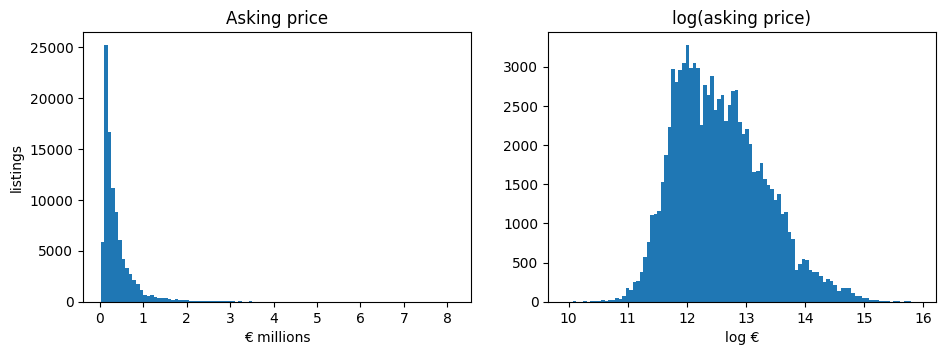

Skewness — price: 4.04, log(price): 0.53


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(raw["PRICE"] / 1e6, bins=100)
axes[0].set(title="Asking price", xlabel="€ millions", ylabel="listings")
axes[1].hist(np.log(raw["PRICE"]), bins=100)
axes[1].set(title="log(asking price)", xlabel="log €")
show(fig, "target_distribution")

print(f"Skewness — price: {raw['PRICE'].skew():.2f}, log(price): {np.log(raw['PRICE']).skew():.2f}")

## 1.6 Listings per quarter

We count the unique flats in each quarter, because our split is done by quarter.

In [6]:
per_q = raw.groupby("PERIOD").agg(unique_flats=("ASSETID", "nunique"),
                                  median_price=("PRICE", "median"))
per_q["share"] = (per_q["unique_flats"] / per_q["unique_flats"].sum()).round(3)
display(per_q)

,unique_flats,median_price,share
PERIOD,,,
201803,17622,256000.0,0.232
201806,12518,247000.0,0.165
201809,14246,253000.0,0.188
201812,31418,274000.0,0.414


## 1.7 What drives price? First look

We plot log(price) against size and distance to the centre, and rank the numeric
columns by how much they correlate with log(price).

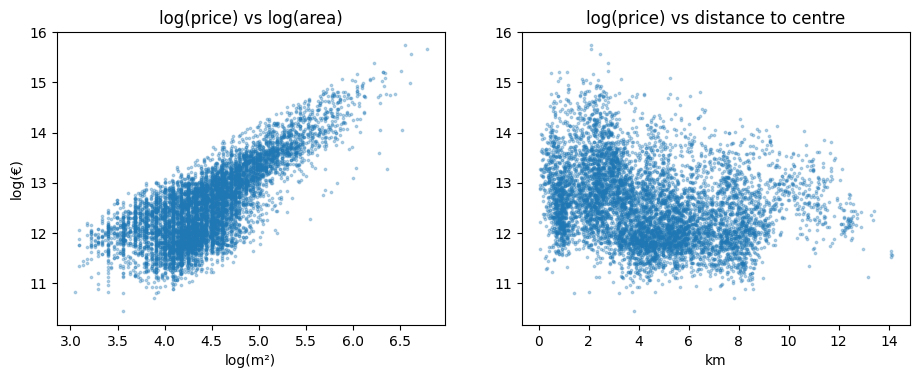

,corr_with_log_price
CONSTRUCTEDAREA,0.756
BATHNUMBER,0.701
CADASTRALQUALITYID,-0.573
HASLIFT,0.492
ROOMNUMBER,0.450
HASDOORMAN,0.426
LATITUDE,0.390
DISTANCE_TO_CASTELLANA,-0.304
HASPARKINGSPACE,0.287
ISPARKINGSPACEINCLUDEDINPRICE,0.287


In [7]:
sample = raw.sample(8000, random_state=SEED)  # fewer points keeps the plots readable

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].scatter(np.log(sample["CONSTRUCTEDAREA"]), np.log(sample["PRICE"]), s=3, alpha=0.3)
axes[0].set(title="log(price) vs log(area)", xlabel="log(m²)", ylabel="log(€)")
axes[1].scatter(sample["DISTANCE_TO_CITY_CENTER"], np.log(sample["PRICE"]), s=3, alpha=0.3)
axes[1].set(title="log(price) vs distance to centre", xlabel="km")
show(fig, "price_relationships")

log_price = np.log(raw["PRICE"])
numeric = raw.select_dtypes("number").drop(columns=["PRICE", "UNITPRICE"])
corr = numeric.corrwith(log_price).sort_values(key=abs, ascending=False)
display(corr.round(3).to_frame("corr_with_log_price"))

## 1.8 Data quality checks

We look for impossible or suspicious values (tiny areas, zero rooms, odd years,
extreme price per m²) that we will need to deal with in cleaning.

In [8]:
checks = {
    "area < 20 m²": (raw["CONSTRUCTEDAREA"] < 20).sum(),
    "area > 500 m²": (raw["CONSTRUCTEDAREA"] > 500).sum(),
    "0 bedrooms (non-studio)": ((raw["ROOMNUMBER"] == 0) & (raw["ISSTUDIO"] == 0)).sum(),
    "0 bathrooms": (raw["BATHNUMBER"] == 0).sum(),
    "cadastre year < 1800": (raw["CADCONSTRUCTIONYEAR"] < 1800).sum(),
    "€/m² < 1,000": (raw["UNITPRICE"] < 1000).sum(),
    "€/m² > 12,000": (raw["UNITPRICE"] > 12000).sum(),
    "> 20 km from centre": (raw["DISTANCE_TO_CITY_CENTER"] > 20).sum(),
}
display(pd.Series(checks, name="rows").to_frame())

both = raw.dropna(subset=["CONSTRUCTIONYEAR"])
gap = (both["CONSTRUCTIONYEAR"] - both["CADCONSTRUCTIONYEAR"]).abs()
print(f"Advertiser vs cadastre year, where both exist ({len(both):,} rows): "
      f"identical {(gap == 0).mean():.0%}, within 5 years {(gap <= 5).mean():.0%}")

print("\nCondition flags (should sum to 1 per row):",
      raw[["BUILTTYPEID_1", "BUILTTYPEID_2", "BUILTTYPEID_3"]].sum(axis=1).value_counts().to_dict())
print("Cadastral quality counts:", raw["CADASTRALQUALITYID"].value_counts().sort_index().to_dict())

,rows
area < 20 m²,0
area > 500 m²,234
0 bedrooms (non-studio),161
0 bathrooms,89
cadastre year < 1800,13
"€/m² < 1,000",474
"€/m² > 12,000",0
> 20 km from centre,1


Advertiser vs cadastre year, where both exist (38,942 rows): identical 99%, within 5 years 99%

Condition flags (should sum to 1 per row): {1: 94815}
Cadastral quality counts: {0.0: 377, 1.0: 629, 2.0: 2703, 3.0: 12634, 4.0: 24673, 5.0: 20725, 6.0: 20491, 7.0: 10428, 8.0: 1527, 9.0: 627}


## 1.9 End of section 1

So far we haven't changed or saved anything except the plots. In section 2 we turn these checks into cleaning decisions.

# Section 2 — Cleaning & deduplication

## 2.0 Cleaning decisions

All our cleaning choices are in this one cell, each with the reason behind it. For example,
we drop flats with 0 bathrooms because every real flat has one, so it has to be a data error.

In [9]:
DUPLICATE_PRICE = "mean"

# Suspicious rows found in 1.8: True = drop, False = keep
DROP_RULES = {
    # Likely not normal sales (partial ownership, occupied, typos): classic false bargains for the investor.
    "€/m² < 1,000": True,
    # Normal-sized flats with a missing/mistyped room count, which would feed the model a wrong key feature.
    "0 bedrooms (non-studio)": True,
    # Every real flat has a bathroom, so 0 is a data-entry error.
    "0 bathrooms": True,
    # One flat has coordinates 415 km away (in Almería): impossible for Madrid, so a data error.
    "> 20 km from centre": True,
}

# Advertiser's construction year: 59% missing, 99% identical to the cadastre year
DROP_ADVERTISER_YEAR = True

# Rows missing floor or interior/exterior
MISSING_FLOOR_LOCATION = "fill"   # options: "fill" (in section 4, + "was missing" flag), "drop"


DROP_REDUNDANT = ["ISPARKINGSPACEINCLUDEDINPRICE","AMENITYID"]

# Condition flags always sum to 1, so one is dropped and becomes the baseline
CONDITION_REFERENCE = "BUILTTYPEID_3"   # good condition, most common

# Quarter is used for the time split
USE_PERIOD_AS_FEATURE = False

## 2.1 Merge duplicate listings

We collapse each flat's copies into one row: the price is combined using `DUPLICATE_PRICE` (the mean),
and every other column is taken from the first copy.

In [10]:
other_cols = [c for c in raw.columns if c not in ("ASSETID", "PRICE")]
agg = {c: "first" for c in other_cols}
agg["PRICE"] = DUPLICATE_PRICE

flats = raw.groupby("ASSETID", as_index=False).agg(agg)
flats["UNITPRICE"] = flats["PRICE"] / flats["CONSTRUCTEDAREA"]  # recompute for the merged price

assert flats["ASSETID"].is_unique
print(f"{len(raw):,} listings -> {len(flats):,} unique flats (price merged with '{DUPLICATE_PRICE}')")

94,815 listings -> 75,804 unique flats (price merged with 'mean')


## 2.2 Remove suspicious rows

We apply the drop rules we chose and show how many flats each rule removes.

In [11]:
unit = flats["UNITPRICE"]
rule_masks = {
    "area > 500 m²": flats["CONSTRUCTEDAREA"] > 500,
    "€/m² < 1,000": unit < 1000,
    "0 bedrooms (non-studio)": (flats["ROOMNUMBER"] == 0) & (flats["ISSTUDIO"] == 0),
    "0 bathrooms": flats["BATHNUMBER"] == 0,
    "cadastre year < 1800": flats["CADCONSTRUCTIONYEAR"] < 1800,
    "> 20 km from centre": flats["DISTANCE_TO_CITY_CENTER"] > 20,
}

drop = pd.Series(False, index=flats.index)
log = []
for rule, mask in rule_masks.items():
    active = DROP_RULES.get(rule, False)   # rules not listed in 2.0 are kept
    log.append({"rule": rule, "flats": int(mask.sum()), "dropped": active})
    if active:
        drop |= mask

display(pd.DataFrame(log))
before = len(flats)
flats = flats[~drop].reset_index(drop=True)
print(f"Removed {before - len(flats):,} flats in total (rules can overlap) -> {len(flats):,} left")

,rule,flats,dropped
0,area > 500 m²,189,False
1,"€/m² < 1,000",421,True
2,0 bedrooms (non-studio),118,True
3,0 bathrooms,70,True
4,cadastre year < 1800,10,False
5,> 20 km from centre,1,True


Removed 564 flats in total (rules can overlap) -> 75,240 left


## 2.3 Drop leaky / redundant columns and handle missing rows

We drop `UNITPRICE` because it's price divided by area, so it would give away the answer (target leakage), and the advertiser's construction
year because the cadastre year already covers it. Rows missing floor or interior info are kept and filled in section 4.

In [12]:
cols_to_drop = ["UNITPRICE"] + DROP_REDUNDANT + [CONDITION_REFERENCE]
if DROP_ADVERTISER_YEAR:
    cols_to_drop.append("CONSTRUCTIONYEAR")
flats = flats.drop(columns=cols_to_drop)
print("Dropped columns:", cols_to_drop)

gap_cols = ["FLOORCLEAN", "FLATLOCATIONID"]
n_missing = flats[gap_cols].isna().any(axis=1).sum()
if MISSING_FLOOR_LOCATION == "drop":
    flats = flats.dropna(subset=gap_cols).reset_index(drop=True)
    print(f"Dropped {n_missing:,} flats missing floor or interior/exterior")
else:
    print(f"Kept {n_missing:,} flats with missing floor or interior/exterior (filled in section 4)")

print("Remaining missing values:", flats.isna().sum()[lambda s: s > 0].to_dict())

Dropped columns: ['UNITPRICE', 'ISPARKINGSPACEINCLUDEDINPRICE', 'AMENITYID', 'BUILTTYPEID_3', 'CONSTRUCTIONYEAR']
Kept 6,832 flats with missing floor or interior/exterior (filled in section 4)
Remaining missing values: {'FLOORCLEAN': 2963, 'FLATLOCATIONID': 4952, 'CADASTRALQUALITYID': 1}


## 2.4 Cleaned data summary

We show the final size and the flats per quarter, and save a cleaning log so the numbers in REPORT.md come straight from here.

In [13]:
import json

summary = flats.groupby("PERIOD").agg(flats=("ASSETID", "size"), median_price=("PRICE", "median"))
summary["share"] = (summary["flats"] / summary["flats"].sum()).round(3)
display(summary)
print(f"Cleaned dataset: {flats.shape[0]:,} flats x {flats.shape[1]} columns")

cleaning_log = {
    "raw_listings": len(raw),
    "duplicate_price": DUPLICATE_PRICE,
    "drop_rules": log,
    "dropped_columns": cols_to_drop,
    "missing_floor_location": MISSING_FLOOR_LOCATION,
    "clean_flats": len(flats),
}
(ARTIFACTS / "cleaning_log.json").write_text(json.dumps(cleaning_log, indent=2, ensure_ascii=False))

,flats,median_price,share
PERIOD,,,
201803,17448,252000.0,0.232
201806,12411,249000.0,0.165
201809,14139,253000.0,0.188
201812,31242,269000.0,0.415


Cleaned dataset: 75,240 flats x 36 columns


815

# Section 3 — Train / validation / test split

## 3.0 Split decisions

We train on Q1–Q3, then split Q4 in half into validation and test, making sure both halves have a similar
mix of cheap and expensive flats.

In [14]:
TRAIN_QUARTERS = [201803, 201806, 201809]   # Q1–Q3 2018
HOLDOUT_QUARTER = 201812                    # Q4 2018, halved into validation + test
VAL_SHARE = 0.5                             # share of Q4 going to validation
PRICE_BANDS = 10                            # price bands used to stratify the Q4 halves

## 3.1 Make the split

We create `train`, `val` and `test`, check that no flat ends up in two sets, and compare
their sizes and median prices.

In [15]:
from sklearn.model_selection import train_test_split

train = flats[flats["PERIOD"].isin(TRAIN_QUARTERS)].reset_index(drop=True)
q4 = flats[flats["PERIOD"] == HOLDOUT_QUARTER].reset_index(drop=True)

bands = pd.qcut(np.log(q4["PRICE"]), PRICE_BANDS, labels=False)
val, test = train_test_split(q4, train_size=VAL_SHARE, stratify=bands, random_state=SEED)
val, test = val.reset_index(drop=True), test.reset_index(drop=True)

ids = [set(df["ASSETID"]) for df in (train, val, test)]
assert not (ids[0] & ids[1] or ids[0] & ids[2] or ids[1] & ids[2]), "A flat appears in two sets"

y_train, y_val, y_test = (np.log(df["PRICE"]).to_numpy() for df in (train, val, test))

split_summary = pd.DataFrame({
    name: {"flats": len(df), "share": round(len(df) / len(flats), 3),
           "median_price": df["PRICE"].median()}
    for name, df in [("train", train), ("val", val), ("test", test)]
}).T
display(split_summary)

,flats,share,median_price
train,43998.0,0.585,252000.0
val,15621.0,0.208,269000.0
test,15621.0,0.208,269000.0


# Section 4 — Feature engineering

## 4.0 Feature decisions

All our feature choices are in one place: the number of location zones, the age bands, which
category is the baseline for each one-hot feature, and how we treat the parking-price column.

In [16]:
N_ZONES = 21                                   # location zones, similar to Madrid's 21 districts
AGE_BAND_EDGES = [-np.inf, 1940, 1960, 1980, 2000, np.inf]
AGE_BAND_LABELS = ["pre1940", "1940_59", "1960_79", "1980_99", "2000plus"]
ADD_LIFT_X_FLOOR = True                        # interaction: floor matters differently with a lift
PARKING_PRICE = "flag"



## 4.1 Learn feature settings from the training set only

Anything that is *learned from the data* is fitted on the training set only: the fill values
for missing data, the 21 location zones, and the baseline category of each one-hot group. This way val and test don't leak into training.

In [17]:
from sklearn.cluster import KMeans

LON_SCALE = np.cos(np.radians(40.42))  # Madrid's latitude


def coords(df):
    return np.c_[df["LATITUDE"], df["LONGITUDE"] * LON_SCALE]


def most_common(series):
    return series.mode().iloc[0]


def fit_feature_state(df):
    """Learn everything data-dependent from the training set only."""
    zones = KMeans(n_clusters=N_ZONES, n_init=10, random_state=SEED).fit(coords(df))
    train_zones = pd.Series(zones.predict(coords(df)))
    age_band = pd.cut(df["CADCONSTRUCTIONYEAR"], AGE_BAND_EDGES, labels=AGE_BAND_LABELS)
    return {
        "floor_fill": float(df["FLOORCLEAN"].median()),
        "exterior_fill": float(most_common(df["FLATLOCATIONID"])),
        "quality_fill": float(most_common(df["CADASTRALQUALITYID"])),
        "zones": zones,
        "baseline": {
            "zone": int(most_common(train_zones)),
            "quality": int(most_common(df["CADASTRALQUALITYID"])),
            "furnishing": int(most_common(df["AMENITYID"])) if "AMENITYID" in df else None,
            "age_band": str(most_common(age_band)),
        },
    }


state = fit_feature_state(train)
print({k: v for k, v in state.items() if k != "zones"})

{'floor_fill': 2.0, 'exterior_fill': 1.0, 'quality_fill': 4.0, 'baseline': {'zone': 18, 'quality': 4, 'furnishing': None, 'age_band': '1960_79'}}


## 4.2 Build the features

One function, `build_features`, turns any set of flats into the table the model uses.
It runs exactly the same way on train, val, test, and later on a flat typed into the dashboard.

In [18]:
AMENITY_FLAGS = ["HASTERRACE", "HASLIFT", "HASAIRCONDITIONING", "HASBOXROOM", "HASWARDROBE",
                 "HASSWIMMINGPOOL", "HASDOORMAN", "HASGARDEN", "HASPARKINGSPACE"]
ORIENTATION_FLAGS = ["HASNORTHORIENTATION", "HASSOUTHORIENTATION",
                     "HASEASTORIENTATION", "HASWESTORIENTATION"]
TYPE_FLAGS = ["ISDUPLEX", "ISSTUDIO", "ISINTOPFLOOR", "BUILTTYPEID_1", "BUILTTYPEID_2"]
AS_IS = (["ROOMNUMBER", "BATHNUMBER", "CADMAXBUILDINGFLOOR",
          "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_CASTELLANA", "DISTANCE_TO_METRO"]
         + AMENITY_FLAGS + ORIENTATION_FLAGS + TYPE_FLAGS)


def one_hot(values, categories, baseline, prefix):
    """Yes/no column per category, leaving out the baseline (fixed categories keep columns identical across sets)."""
    cat = pd.Categorical(values, categories=categories)
    dummies = pd.get_dummies(cat, prefix=prefix, dtype=float)
    return dummies.drop(columns=f"{prefix}_{baseline}")


def build_features(df, state):
    X = pd.DataFrame(index=df.index)
    X[AS_IS] = df[AS_IS].astype(float)
    X["LOG_AREA"] = np.log(df["CONSTRUCTEDAREA"])
    X["LOG_DWELLINGS"] = np.log1p(df["CADDWELLINGCOUNT"])

    X["FLOOR"] = df["FLOORCLEAN"].fillna(state["floor_fill"])
    X["FLOOR_MISSING"] = df["FLOORCLEAN"].isna().astype(float)
    if ADD_LIFT_X_FLOOR:
        X["FLOOR_X_LIFT"] = X["FLOOR"] * df["HASLIFT"]

    exterior_code = df["FLATLOCATIONID"].fillna(state["exterior_fill"])
    X["IS_EXTERIOR"] = (exterior_code == 1).astype(float)   # 1 = exterior, 2 = interior
    X["EXTERIOR_MISSING"] = df["FLATLOCATIONID"].isna().astype(float)

    if PARKING_PRICE == "flag":
        X["PARKING_PRICE_LISTED"] = (df["PARKINGSPACEPRICE"] > 1).astype(float)

    b = state["baseline"]
    quality = df["CADASTRALQUALITYID"].fillna(state["quality_fill"]).astype(int)
    age_band = pd.cut(df["CADCONSTRUCTIONYEAR"], AGE_BAND_EDGES, labels=AGE_BAND_LABELS).astype(str)
    zone = state["zones"].predict(coords(df))

    parts = [
        X,
        one_hot(quality.to_numpy(), range(10), b["quality"], "QUALITY"),
        one_hot(age_band.to_numpy(), AGE_BAND_LABELS, b["age_band"], "AGE"),
        one_hot(zone, range(N_ZONES), b["zone"], "ZONE"),
    ]
    if "AMENITYID" in df:   # skipped if AMENITYID was dropped in 2.0
        parts.append(one_hot(df["AMENITYID"].to_numpy(), [1, 2, 3], b["furnishing"], "FURNISHING"))
    for p in parts[1:]:
        p.index = df.index
    return pd.concat(parts, axis=1)


X_train, X_val, X_test = (build_features(df, state) for df in (train, val, test))
FEATURES = list(X_train.columns)

assert list(X_val.columns) == FEATURES and list(X_test.columns) == FEATURES
assert not any(X.isna().any().any() for X in (X_train, X_val, X_test)), "Missing values left"
print(f"{len(FEATURES)} features | train {X_train.shape} | val {X_val.shape} | test {X_test.shape}")

65 features | train (43998, 65) | val (15621, 65) | test (15621, 65)


## 4.3 Sanity checks

We map the 21 zones and check the age-band pattern on the training set, to make sure
the features actually capture what we wanted.

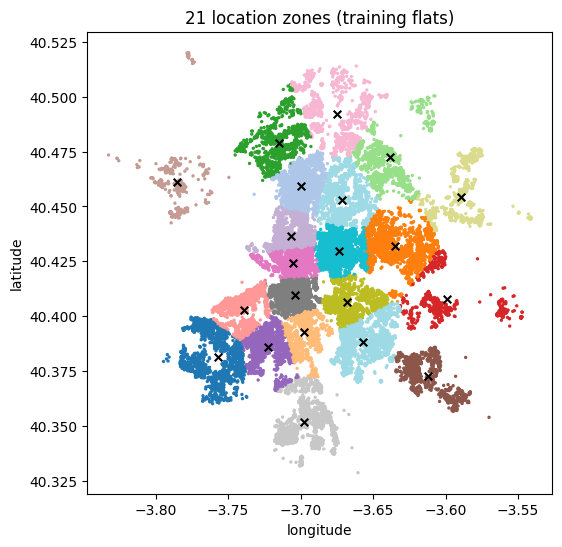

,median log €/m²,flats
CADCONSTRUCTIONYEAR,,
pre1940,8.469,7586
1940_59,8.114,8632
1960_79,7.905,15970
1980_99,8.052,6130
2000plus,8.093,5680


In [19]:
train_zone = state["zones"].predict(coords(train))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(train["LONGITUDE"], train["LATITUDE"], c=train_zone, cmap="tab20", s=2)
centres = state["zones"].cluster_centers_
ax.scatter(centres[:, 1] / LON_SCALE, centres[:, 0], c="black", marker="x", s=30)
ax.set(title=f"{N_ZONES} location zones (training flats)", xlabel="longitude", ylabel="latitude")
show(fig, "zone_map")

log_price_m2 = np.log(train["PRICE"] / train["CONSTRUCTEDAREA"])
train_age_band = pd.cut(train["CADCONSTRUCTIONYEAR"], AGE_BAND_EDGES, labels=AGE_BAND_LABELS)
display(log_price_m2.groupby(train_age_band, observed=True).agg(["median", "size"]).round(3)
        .rename(columns={"median": "median log €/m²", "size": "flats"}))

# Section 5 — Preprocessing

## 5.1 Standardize numeric features (fitted on train)

We rescale the numeric columns to mean 0 and standard deviation 1, using training
data only. The yes/no flags stay as 0/1, so their coefficients still read as "having a lift adds X%".

In [20]:
NUMERIC = [c for c in FEATURES if not set(np.unique(X_train[c])) <= {0.0, 1.0}]
FLAGS = [c for c in FEATURES if c not in NUMERIC]

scaler = {"columns": NUMERIC,
          "mean": X_train[NUMERIC].mean(),
          "std": X_train[NUMERIC].std()}


def scale(X, scaler):
    X = X.copy()
    cols = scaler["columns"]
    X[cols] = (X[cols] - scaler["mean"]) / scaler["std"]
    return X.to_numpy(dtype=np.float64)


Xs_train, Xs_val, Xs_test = (scale(X, scaler) for X in (X_train, X_val, X_test))
print(f"Standardized {len(NUMERIC)} numeric columns: {NUMERIC}")
print(f"Kept {len(FLAGS)} yes/no columns as 0/1")
check = pd.DataFrame(Xs_train, columns=FEATURES)[NUMERIC]
assert np.allclose(check.mean(), 0, atol=1e-9) and np.allclose(check.std(), 1), "Scaling went wrong"

Standardized 10 numeric columns: ['ROOMNUMBER', 'BATHNUMBER', 'CADMAXBUILDINGFLOOR', 'DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_CASTELLANA', 'DISTANCE_TO_METRO', 'LOG_AREA', 'LOG_DWELLINGS', 'FLOOR', 'FLOOR_X_LIFT']
Kept 55 yes/no columns as 0/1


# Section 6 — Baseline + three implementations of linear regression

## 6.0 Training settings

Full-batch means every step uses all 44k training flats to compute the
gradient, so training is smooth and gives the same result every time. We chose the learning rate by trying a few
values (6.1): too big and the loss explodes, too small and training needs way more steps. We need a lot of
epochs because some one-hot columns are rare (e.g. a quality level only a few hundred flats
have), so their gradients are small and their weights move slowly. If we stopped early, those
weights wouldn't be finished, and we would see it as disagreement with scikit-learn.

In [21]:
import torch

torch.manual_seed(SEED)
LEARNING_RATE = 0.1       # 0.3 diverged in the check below; 0.2 is the largest stable value tried
EPOCHS = 10_000           # full-batch gradient-descent steps
LOG_EVERY = 100           # record train/val loss every N epochs (for the learning-curve plot)
RUN_LR_CHECK = True       # set False to skip the learning-rate check and save ~15 seconds

Xt_train, Xt_val = (torch.tensor(X, dtype=torch.float32) for X in (Xs_train, Xs_val))
yt_train, yt_val = (torch.tensor(y, dtype=torch.float32) for y in (y_train, y_val))

## 6.1 Learning-rate check

We train the manual model briefly with a few learning rates and compare the validation
loss, to back up the value we chose.

In [22]:
def gd_manual(X, y, lr, epochs, X_val=None, y_val=None, log_every=None):
    """Linear regression by hand: raw tensors, autograd for gradients, manual weight update."""
    w = torch.zeros(X.shape[1], requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    history = []
    for epoch in range(1, epochs + 1):
        pred = X @ w + b
        loss = ((pred - y) ** 2).mean()          # mean squared error
        loss.backward()                          # autograd fills w.grad and b.grad
        with torch.no_grad():                    # update weights without tracking it as a computation
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()
        if not torch.isfinite(loss):
            history.append((epoch, float("nan"), float("nan")))
            break
        if log_every and epoch % log_every == 0:
            with torch.no_grad():
                val_loss = ((X_val @ w + b - y_val) ** 2).mean().item()
            history.append((epoch, loss.item(), val_loss))
    return w.detach(), b.detach(), history


if RUN_LR_CHECK:
    rows = []
    for lr in [0.05, 0.1, 0.2, 0.3]:
        _, _, h = gd_manual(Xt_train, yt_train, lr, 2000, Xt_val, yt_val, log_every=2000)
        rows.append({"learning_rate": lr, "val_MSE_after_2000": h[-1][2]})
    display(pd.DataFrame(rows))

,learning_rate,val_MSE_after_2000
0,0.05,0.064922
1,0.10,0.057570
2,0.20,0.055378
3,0.30,NaN


## 6.2 Evaluation metrics and naive baseline

We define the metrics we use everywhere, then score a naive baseline that predicts the
same price (the training average) for every flat. Any model has to beat this to be worth it.

In [23]:
def evaluate(y_true, y_pred):
    err = y_pred - y_true
    return {
        "RMSE_log": float(np.sqrt(np.mean(err ** 2))),
        "median_abs_pct_error": float(np.median(np.abs(np.exp(err) - 1))),
        "R2": float(1 - np.sum(err ** 2) / np.sum((y_true - y_true.mean()) ** 2)),
    }


baseline_value = float(y_train.mean())
val_preds = {"baseline": np.full_like(y_val, baseline_value)}
print(f"Baseline predicts log price {baseline_value:.3f} (≈ €{np.exp(baseline_value):,.0f}) for every flat")
print(evaluate(y_val, val_preds["baseline"]))

Baseline predicts log price 12.524 (≈ €274,802) for every flat
{'RMSE_log': 0.758508760321148, 'median_abs_pct_error': 0.5182405579294307, 'R2': -0.00773194254972287}


## 6.3 Method 1 — scikit-learn

We fit `LinearRegression`. It solves for the best weights directly (least squares),
with no learning rate or epochs, so we use it as the reference answer.

In [24]:
from sklearn.linear_model import LinearRegression

sk_model = LinearRegression().fit(Xs_train, y_train)
val_preds["sklearn"] = sk_model.predict(Xs_val)
print(evaluate(y_val, val_preds["sklearn"]))

{'RMSE_log': 0.2336415943958692, 'median_abs_pct_error': 0.1417703246586427, 'R2': 0.9043854147922737}


## 6.4 Method 2 — manual PyTorch loop

Each epoch, we predict with `X @ w + b`, compute the
mean squared error, and call `.backward()` so autograd works out how the loss changes with each weight.
Then we step every weight a little against its gradient. `torch.no_grad()` stops PyTorch from treating
the update itself as part of the model, and we zero the gradients after each step because PyTorch
*adds* new gradients to the old ones by default. Weights start at zero, and we record train and validation loss
every `LOG_EVERY` epochs for the learning-curve plot.

In [25]:
import time

t0 = time.time()
w_manual, b_manual, hist_manual = gd_manual(Xt_train, yt_train, LEARNING_RATE, EPOCHS,
                                            Xt_val, yt_val, log_every=LOG_EVERY)
val_preds["manual_pytorch"] = (Xt_val @ w_manual + b_manual).numpy().astype(np.float64)
print(f"Trained in {time.time() - t0:.1f}s")
print(evaluate(y_val, val_preds["manual_pytorch"]))

Trained in 13.7s
{'RMSE_log': 0.23371523663794025, 'median_abs_pct_error': 0.14127543775657614, 'R2': 0.904325131158889}


## 6.5 Method 3 — standard PyTorch (`nn.Module` + `torch.optim`)

This does what we did by hand, but with PyTorch's building blocks. `nn.Linear`
holds the weights and bias, `nn.MSELoss` computes the loss, and `optim.SGD` does exactly the
`w -= lr * grad` update, while `optimizer.zero_grad()` replaces the manual zeroing. With full-batch data
and plain SGD (no momentum, no weight decay), the maths is the same as 6.4. The one difference is that
`nn.Linear` starts from small random weights instead of zeros, so the two PyTorch versions take
slightly different paths to the same answer.

In [26]:
from torch import nn, optim


class LinearRegressionModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


torch.manual_seed(SEED)
nn_model = LinearRegressionModel(Xt_train.shape[1])
loss_fn = nn.MSELoss()
optimizer = optim.SGD(nn_model.parameters(), lr=LEARNING_RATE)

hist_nn = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    nn_model.train()
    optimizer.zero_grad()
    loss = loss_fn(nn_model(Xt_train), yt_train)
    loss.backward()
    optimizer.step()
    if epoch % LOG_EVERY == 0:
        nn_model.eval()
        with torch.no_grad():
            hist_nn.append((epoch, loss.item(), loss_fn(nn_model(Xt_val), yt_val).item()))

nn_model.eval()
with torch.no_grad():
    val_preds["standard_pytorch"] = nn_model(Xt_val).numpy().astype(np.float64)
print(f"Trained in {time.time() - t0:.1f}s")
print(evaluate(y_val, val_preds["standard_pytorch"]))

Trained in 13.6s
{'RMSE_log': 0.23371582446541198, 'median_abs_pct_error': 0.14129351214555053, 'R2': 0.9043246498861419}


## 6.6 Do the three agree? (validation set)

We compare all methods on the validation set, then check how close the PyTorch
predictions and weights are to scikit-learn's, and plot the training curves.

,RMSE_log,median_abs_pct_error,R2
baseline,0.7585,0.5182,-0.0077
sklearn,0.2336,0.1418,0.9044
manual_pytorch,0.2337,0.1413,0.9043
standard_pytorch,0.2337,0.1413,0.9043


,max |pred diff| vs sklearn (log),max |coef diff| vs sklearn
manual_pytorch,0.02411,0.05009
standard_pytorch,0.02432,0.05048


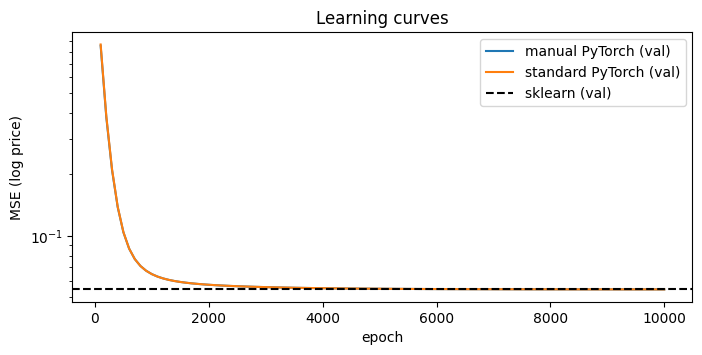

In [27]:
val_results = pd.DataFrame({name: evaluate(y_val, p) for name, p in val_preds.items()}).T
display(val_results.round(4))

coefs = {
    "sklearn": np.r_[sk_model.intercept_, sk_model.coef_],
    "manual_pytorch": np.r_[b_manual.numpy(), w_manual.numpy()],
    "standard_pytorch": np.r_[nn_model.linear.bias.detach().numpy(),
                              nn_model.linear.weight.detach().numpy().ravel()],
}
agreement = pd.DataFrame({
    name: {"max |pred diff| vs sklearn (log)": np.abs(val_preds[name] - val_preds["sklearn"]).max(),
           "max |coef diff| vs sklearn": np.abs(coefs[name] - coefs["sklearn"]).max()}
    for name in ["manual_pytorch", "standard_pytorch"]
}).T
display(agreement.round(5))

fig, ax = plt.subplots(figsize=(8, 3.5))
for name, hist in [("manual PyTorch", hist_manual), ("standard PyTorch", hist_nn)]:
    h = np.array(hist)
    ax.plot(h[:, 0], h[:, 2], label=f"{name} (val)")
ax.axhline(val_results.loc["sklearn", "RMSE_log"] ** 2, color="black", ls="--", label="sklearn (val)")
ax.set(yscale="log", xlabel="epoch", ylabel="MSE (log price)", title="Learning curves")
ax.legend()
show(fig, "learning_curves")

# Section 7 — Regularization check, margin of safety, final test & saving

## 7.0 Settings

Here we set how much better a regularized model has to be to replace the plain one, which
validation error percentile sets the margin of safety, and the 50% upper cap from our business framing.

In [28]:
RIDGE_ALPHAS = [0.1, 1, 10, 100, 1000]   # regularization strengths to try (validation only)
RIDGE_MIN_GAIN = 0.005                   # adopt Ridge only if val RMSE improves by ≥ 0.5%

MARGIN_PERCENTILE = 75                   # options: 50 (median), 75, 90 — percentile of validation % error
MAX_DISCOUNT = 0.50                      # listings > 50% below the estimate are excluded as suspicious

## 7.1 Does the model overfit? Is Ridge needed?

We compare the training and validation error, then try Ridge with a few strengths. We only use Ridge
if it clearly helps; otherwise the simpler model wins.

In [29]:
from sklearn.linear_model import Ridge

rmse = lambda y, p: float(np.sqrt(np.mean((p - y) ** 2)))
train_rmse = rmse(y_train, sk_model.predict(Xs_train))
val_rmse = rmse(y_val, val_preds["sklearn"])
print(f"Plain linear regression — train RMSE {train_rmse:.4f} | val RMSE {val_rmse:.4f} "
      f"| gap {val_rmse - train_rmse:+.4f}")

ridge_results = pd.DataFrame([
    {"alpha": a, "val_RMSE_log": rmse(y_val, Ridge(alpha=a).fit(Xs_train, y_train).predict(Xs_val))}
    for a in RIDGE_ALPHAS
])
display(ridge_results.round(5))

best = ridge_results.loc[ridge_results["val_RMSE_log"].idxmin()]
gain = 1 - best["val_RMSE_log"] / val_rmse
USE_RIDGE = gain >= RIDGE_MIN_GAIN
print(f"Best alpha {best['alpha']}: {gain:.2%} better than plain on validation -> "
      f"{'adopt Ridge' if USE_RIDGE else 'not needed, keep plain linear regression'}")

Plain linear regression — train RMSE 0.2412 | val RMSE 0.2336 | gap -0.0076


,alpha,val_RMSE_log
0,0.1,0.23364
1,1.0,0.23365
2,10.0,0.23375
3,100.0,0.23610
4,1000.0,0.25605


Best alpha 0.1: -0.00% better than plain on validation -> not needed, keep plain linear regression


## 7.2 Margin of safety from validation errors

We turn the model's validation errors into the bargain threshold: a listing only counts
as a bargain if it's at least the margin below its estimated market price (and not more than
50% below, because then something is probably wrong with the listing).

In [30]:
def pct_vs_estimate(log_listing, log_estimate):
    """Listing price relative to the estimate: -0.20 = listed 20% below the estimated market price."""
    return np.exp(log_listing - log_estimate) - 1


def is_bargain(pct, margin, max_discount=MAX_DISCOUNT):
    return (pct <= -margin) & (pct > -max_discount)


val_pct = pct_vs_estimate(y_val, val_preds["sklearn"])
options = []
for p in [50, 75, 90]:
    m = float(np.percentile(np.abs(val_pct), p))
    flagged = is_bargain(val_pct, m)
    options.append({"percentile": p, "margin": m, "bargains_flagged": int(flagged.sum()),
                    "share_of_listings": flagged.mean()})
display(pd.DataFrame(options).round(3))

MARGIN = float(np.percentile(np.abs(val_pct), MARGIN_PERCENTILE))
print(f"Chosen margin of safety ({MARGIN_PERCENTILE}th percentile): {MARGIN:.1%} below estimate, "
      f"capped at {MAX_DISCOUNT:.0%}. Excluded as suspicious (> cap): {(val_pct <= -MAX_DISCOUNT).sum()}")

,percentile,margin,bargains_flagged,share_of_listings
0,50,0.145,2553,0.163
1,75,0.260,922,0.059
2,90,0.397,168,0.011


Chosen margin of safety (75th percentile): 26.0% below estimate, capped at 50%. Excluded as suspicious (> cap): 73


## 7.3 Final evaluation on the test set (used once)

We score the baseline and all three models on the untouched test set, and count how
many test listings the chosen margin flags as bargains.

In [31]:
Xt_test = torch.tensor(Xs_test, dtype=torch.float32)
with torch.no_grad():
    test_preds = {
        "baseline": np.full_like(y_test, baseline_value),
        "sklearn": sk_model.predict(Xs_test),
        "manual_pytorch": (Xt_test @ w_manual + b_manual).numpy().astype(np.float64),
        "standard_pytorch": nn_model(Xt_test).numpy().astype(np.float64),
    }

test_results = pd.DataFrame({name: evaluate(y_test, p) for name, p in test_preds.items()}).T
display(test_results.round(4))

test_pct = pct_vs_estimate(y_test, test_preds["sklearn"])
test_bargains = is_bargain(test_pct, MARGIN)
print(f"Test listings flagged as bargains: {test_bargains.sum():,} of {len(y_test):,} "
      f"({test_bargains.mean():.1%})")

,RMSE_log,median_abs_pct_error,R2
baseline,0.7591,0.5182,-0.0080
sklearn,0.2366,0.1451,0.9021
manual_pytorch,0.2366,0.1450,0.9021
standard_pytorch,0.2366,0.1450,0.9021


Test listings flagged as bargains: 915 of 15,621 (5.9%)


## 7.4 Save everything the dashboard needs

The brief says training can only happen here, so we save everything the app needs
to disk:
- **Models:** scikit-learn (joblib), the manual PyTorch weights, and the `nn.Module` state dict.
- **Pipeline:** the feature settings learned on train (zones, fill values, baselines), the scaler, the feature list and
  settings, so new flats get treated exactly the same way.
- **`predictions.csv`:** every flat with its split, actual price, each model's prediction and a few raw
  features. This powers the prediction-vs-actual plot and the distribution views.
- **`eval_flats.csv`:** the val/test flats' features and details, so the dashboard's Home hub can
  explain why each bargain gets its estimate.
- **`metrics.json`** and **`learning_curves.csv`:** the numbers for REPORT.md and the dashboard,
  produced by the pipeline instead of copied by hand.

In [32]:
import joblib

MODELS = ARTIFACTS / "models"
MODELS.mkdir(exist_ok=True)

joblib.dump(sk_model, MODELS / "sklearn_linear.joblib")
torch.save({"w": w_manual, "b": b_manual}, MODELS / "manual_pytorch.pt")
torch.save(nn_model.state_dict(), MODELS / "standard_pytorch.pt")

joblib.dump({
    "state": state, "scaler": scaler, "features": FEATURES, "numeric": NUMERIC,
    "n_zones": N_ZONES, "age_band_edges": AGE_BAND_EDGES, "age_band_labels": AGE_BAND_LABELS,
    "lon_scale": LON_SCALE, "margin": MARGIN, "max_discount": MAX_DISCOUNT,
    "train_feature_means": X_train.mean(),   # the "typical flat" used to explain each estimate
}, ARTIFACTS / "pipeline.joblib")

# Feature table + display details for val/test flats, so the dashboard's Home hub can
# explain each estimate with the loaded models (nothing is retrained there)
SHOW_COLS = ["ASSETID", "PRICE", "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER", "FLOORCLEAN",
             "HASLIFT", "HASTERRACE", "HASAIRCONDITIONING", "HASPARKINGSPACE", "HASDOORMAN",
             "HASSWIMMINGPOOL", "HASGARDEN", "HASBOXROOM", "HASWARDROBE", "FLATLOCATIONID",
             "CADASTRALQUALITYID", "CADCONSTRUCTIONYEAR", "BUILTTYPEID_1", "BUILTTYPEID_2",
             "ISDUPLEX", "ISSTUDIO", "ISINTOPFLOOR", "DISTANCE_TO_CITY_CENTER", "DISTANCE_TO_METRO"]
eval_frames = []
for split, df, X in [("val", val, X_val), ("test", test, X_test)]:
    show = df[SHOW_COLS].reset_index(drop=True)
    feats = X.reset_index(drop=True).add_prefix("f_")
    eval_frames.append(pd.concat([show.assign(split=split), feats], axis=1))
pd.concat(eval_frames, ignore_index=True).to_csv(ARTIFACTS / "eval_flats.csv", index=False)

# Predictions + key raw details for every flat (train predictions included for completeness)
with torch.no_grad():
    Xt_train_all = torch.tensor(Xs_train, dtype=torch.float32)
    train_preds = {
        "baseline": np.full_like(y_train, baseline_value),
        "sklearn": sk_model.predict(Xs_train),
        "manual_pytorch": (Xt_train_all @ w_manual + b_manual).numpy().astype(np.float64),
        "standard_pytorch": nn_model(Xt_train_all).numpy().astype(np.float64),
    }

DETAIL_COLS = ["ASSETID", "PERIOD", "PRICE", "CONSTRUCTEDAREA", "ROOMNUMBER", "BATHNUMBER",
               "CADCONSTRUCTIONYEAR", "DISTANCE_TO_CITY_CENTER", "LATITUDE", "LONGITUDE"]
frames = []
for split, df, preds in [("train", train, train_preds), ("val", val, val_preds), ("test", test, test_preds)]:
    out = df[DETAIL_COLS].copy()
    out["split"] = split
    out["zone"] = state["zones"].predict(coords(df))
    out["log_price"] = np.log(df["PRICE"])
    for name, p in preds.items():
        out[f"pred_{name}"] = p
    frames.append(out)
pd.concat(frames, ignore_index=True).to_csv(ARTIFACTS / "predictions.csv", index=False)

pd.DataFrame(
    [(e, tr, va, "manual_pytorch") for e, tr, va in hist_manual]
    + [(e, tr, va, "standard_pytorch") for e, tr, va in hist_nn],
    columns=["epoch", "train_mse", "val_mse", "model"],
).to_csv(ARTIFACTS / "learning_curves.csv", index=False)

metrics = {
    "validation": val_results.to_dict(orient="index"),
    "test": test_results.to_dict(orient="index"),
    "agreement_vs_sklearn": agreement.to_dict(orient="index"),
    "train_rmse": train_rmse,
    "ridge": {"results": ridge_results.to_dict(orient="records"), "best_alpha": float(best["alpha"]),
              "gain": float(gain), "adopted": bool(USE_RIDGE)},
    "margin": {"percentile": MARGIN_PERCENTILE, "value": MARGIN, "max_discount": MAX_DISCOUNT,
               "options": options, "test_bargains": int(test_bargains.sum())},
    "training": {"learning_rate": LEARNING_RATE, "epochs": EPOCHS},
    "n_features": len(FEATURES),
}
(ARTIFACTS / "metrics.json").write_text(json.dumps(metrics, indent=2, default=float))

print("Saved to artifacts/:")
for p in sorted(ARTIFACTS.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(ARTIFACTS)}  ({p.stat().st_size / 1e6:.2f} MB)")

Saved to artifacts/:
  cleaning_log.json  (0.00 MB)
  eval_flats.csv  (14.27 MB)
  learning_curves.csv  (0.01 MB)
  learning_curves.png  (0.03 MB)
  metrics.json  (0.00 MB)
  models/manual_pytorch.pt  (0.00 MB)
  models/sklearn_linear.joblib  (0.00 MB)
  models/standard_pytorch.pt  (0.00 MB)
  pipeline.joblib  (0.18 MB)
  predictions.csv  (15.36 MB)
  price_relationships.png  (0.20 MB)
  target_distribution.png  (0.03 MB)
  zone_map.png  (0.14 MB)
